# LFS 2022: exploring the data before we decide anything

<small>We're looking at the raw data before committing to any modeling choice. This notebook is
organized around the actual questions each file can answer, not a column-by-column tour. Two
files, structured completely differently:<br>
- <b>Part 1</b>: individual file, one row per person<br>
- <b>Part 2</b>: household file, one row per household (head + up to 3 spouses spread across columns)<br>
- <b>Part 3</b>: what only combining them can tell us<br>
CAPMAS/ERF, 2022.</small>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

REPO_ROOT = Path.cwd().parent
BASE = REPO_ROOT / "Data" / "Labor Force Survey, LFS 2022 - Egypt, Arab Rep., 2022"

ind = pd.read_stata(BASE / "Egypt 2022-LFS IND-V1.dta", convert_categoricals=False)
hh = pd.read_stata(BASE / "Egypt 2022-LFS HH-V1.dta", convert_categoricals=False)
dictionary = pd.read_csv(REPO_ROOT / "Data" / "LFS2022_data_dictionary_extracted.csv")

MALE_C, FEMALE_C = "#2a78d6", "#1baf7a"
GRID_C, AXIS_C, TEXT_C = "#e1e0d9", "#898781", "#52514e"
mpl.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": AXIS_C, "axes.labelcolor": TEXT_C,
    "xtick.color": TEXT_C, "ytick.color": TEXT_C,
    "grid.color": GRID_C, "text.color": "#0b0b0b",
    "font.family": "sans-serif", "figure.facecolor": "white",
})

def describe(*varnames):
    """Look up a column's real definition from the data dictionary. Not called anywhere below
    anymore (the keep/drop table covers the columns we actually use); kept here as a utility if
    you want to check any other column ad hoc, e.g. describe("empcont")."""
    for v in varnames:
        row = dictionary[dictionary["var_name"].astype(str).str.strip().str.upper() == v.upper()]
        if len(row):
            r = row.iloc[0]
            print(f"{v}: {r['var_label']}")
            print(f"  universe: {r['universe']}")
            if pd.notna(r['comments_formula']):
                print(f"  note: {str(r['comments_formula'])[:250]}")
        else:
            print(f"{v}: not found in dictionary")
        print()

print("individual file:", ind.shape)
print("household file:", hh.shape)

individual file: (299423, 106)
household file: (76976, 116)


<small>The `describe()` function defined above just looks up a column's real definition from the
official data dictionary, so we don't have to re-type explanations by hand. It's not used anywhere
below (the keep/drop table covers every column we actually use), but it's there if you want to
check any other column yourself, e.g. `describe("empcont")`.</small>

### What we're keeping vs. dropping, and why

<small>

106 columns in the individual file, 116 in the household file. Most isn't relevant to what we're doing. One table each, not a wall of prose:

**Individual file**

| Column(s) | What it is | Keep/Drop | Why |
|---|---|---|---|
| `caseser`, `pnum` | Household ID + person ID within it | Keep | Links to the household file and to household-enrichment features |
| `pweight` | Survey sampling weight | Keep | Not used yet, but needed for any population-representative claim later |
| `reg`, `rururb` | Governorate, urban/rural | Keep | Core geography |
| `age`, `sex`, `mart`, `lit`, `educ` | Age, gender, marital status, literacy, education | Keep | Core demographics |
| `yeduc` | Years of effective schooling | Keep | Continuous alternative to `educ`'s 6 buckets, likely a stronger wage/hours-model feature |
| `rel` | Relationship to household head | Keep | Needed for household-enrichment joins |
| `immigr` | Migration status | Keep | Checked directly (see the migration check below) |
| `ind`, `occ`, `sector` | Industry, occupation, employment sector | Keep | Defines "agriculture," cross-checked against each other |
| `emps`, `empstab`, `empcont` | Employment status, stability, contract | Keep | Core: who's paid vs. unpaid, formal vs. informal |
| `hlthins`, `socsec` | Health insurance, social security coverage | Keep | Effectively full coverage among the employed, a cleaner formal/informal signal than `empstab`/`empcont` alone |
| `wrkplc` | Where the work happens (type of location) | Keep | Confirms agricultural workers are actually working the land |
| `gwrkplc` | Geographical workplace (governorate of work) | Checked, mostly unusable | Would directly test whether people work outside their residence governorate (the assumption the whole spatial linkage relies on). But 95% of agricultural workers have it coded "not stated," vs. 1-8% for most other industries, so there isn't enough of it for the population this paper is about |
| `hrswk`, `hrswksc` | Weekly hours, main + secondary job | Keep | Primary target |
| `totwag`, `irrgwag`, `empinc`, `sempinc` | Wage and income variables | Keep | Secondary target (wage) |
| `mart_d`, `rel_d`, `educ_d`, `occ_08`, `occ_isco88_4`, `occ_isco08_4`, `occ_com_4`, `ind_isic4_4`, `sector_d` | "Detailed version" / alternate-coding duplicates | Drop | Redundant with the standardized version we already keep |
| `rdus_wag_inc_cvd`, `rduswrkd_r_cvd`, `rdus_ratio_cvd`, `lvprvj_r_cvd` | COVID-19 impact | Drop | Checked directly, mostly empty by 2022, not worth a dedicated section |
| `tdisabl_01`-`06`, `disabl` | Disability status/sub-type | Drop | Same restricted ~22%-populated universe as `bir`, low value |
| `srchact_01`-`10`, `notsrch_r`, `unempdur` | Job-search method, unemployment duration | Drop | Too granular, about unemployment spells not current work |
| `occsc*`, `hrswksc`'s siblings, `occprv*`, `indprv*`, `sectorprv*` | Secondary-job and previous-job detail | Drop | Secondary/previous jobs are rare, not our question |
| `bir`, `curresd_r` | Born in current residence, reason for moving | Drop | Same restricted universe as `immigr`, redundant with it |
| `benefit_01`-`03`, `fhrswk_r_*` | Benefit detail, reasons for reduced hours | Drop | Heavily conditional sub-questions, low coverage |

**Household file**

| Column(s) | What it is | Keep/Drop | Why |
|---|---|---|---|
| `caseser` | Household ID | Keep | Links to the individual file |
| `reg`, `rururb` | Geography | Keep | Matches the individual file |
| `tpnum`, `malnum`, `femnum` | Household size and composition | Keep | Household context |
| `malinlf`, `feminlf` | Household members 15+ in the labor force, by sex | Keep | 100% populated, official CAPMAS count; a ready-made household-level gender-labor-participation measure |
| `sexhd`, `agehd`, `eduhd`, `lithd`, `marthd` | Head's demographics | Keep | Household head context |
| `empshd`, `indhd`, `sectorhd`, `empstabhd`, `occhd` | Head's job | Keep | Mirrors the individual job variables, for the head; `occhd` added for parity with individual-file `occ` |
| `totwaghd`, `irrgwaghd`, `empinchd`, `sempinchd` | Head's wage/income | Keep | Head's earnings |
| Same set with `sp_1`/`sp_2`/`sp_3` suffix | Spouse(s)' equivalent | Keep | Spouse earnings/demographics |
| `marthd_d`, `eduhd_d`, `sectorhd_d`, `occhd_08`, `occhd_isco88_4`, `occhd_isco08_4`, `indhd_isic4_4`, etc. | "Detailed version" / alternate-coding duplicates | Drop | Redundant with the standardized version we already keep |
| `birhd`, `birsp_*`, `immigrhd`, `immigrsp_*` | Birthplace, head/spouse migration status | Drop | `immigrhd` is only ~25% populated and not clearly different by household headship when checked; not worth a second migration variable on top of the individual-file one |
| `maloutlf`, `femoutlf`, `houtlf`, `hinlf`, `malunemp_pw`/`nw`, `femunemp_pw`/`nw`, `hunemp_pw`/`nw` | Out-of-labor-force and unemployment counts by sex | Drop (for now) | Genuinely useful, out of scope right now, worth revisiting |

</small>

### About `pweight`

<small>LFS is a stratified, clustered sample: not every person represents the same number of
people nationally. `pweight` exists in both files and we're not using it yet anywhere in this
project. Every raw count in this notebook is unweighted, a real number of survey respondents,
not a population estimate. Flagging this now so it doesn't get lost.</small>

# Part 1: what the individual file can answer

In [2]:
ind.sample(5, random_state=1)[["caseser","pnum","sex","age","rururb","ind","occ","emps","totwag","irrgwag","hrswk"]]

,caseser,pnum,sex,age,rururb,ind,occ,emps,totwag,irrgwag,hrswk
195711,2.112152e+11,3,2,6,0,NaN,NaN,NaN,NaN,NaN,NaN
211049,2.206072e+11,1,1,40,0,50.0,70.0,1.0,NaN,130.0,45.0
4761,2.010915e+09,3,1,29,1,60.0,50.0,1.0,1800.0,NaN,52.0
217751,2.303011e+11,5,2,65,1,NaN,NaN,NaN,NaN,NaN,NaN
58785,2.310012e+10,2,2,38,1,NaN,NaN,NaN,NaN,NaN,NaN


<small>A sample of raw rows, not summary stats. Most people have blank job/wage columns since most rows aren't employed adults.</small>

### Question 1: do men and women earn differently, and for what kind of work

In [3]:
wage_earners = ind[(ind["totwag"]>0) | (ind["irrgwag"]>0)]
wage_earners.sample(5, random_state=2)[["sex","age","ind","emps","totwag","irrgwag","hrswk"]]

,sex,age,ind,emps,totwag,irrgwag,hrswk
5223,1,23,60.0,1.0,3500.0,NaN,62.0
205770,1,46,30.0,1.0,3000.0,NaN,45.0
250406,1,32,10.0,1.0,NaN,80.0,48.0
39887,2,18,30.0,1.0,2000.0,NaN,48.0
290981,1,30,50.0,1.0,NaN,60.0,36.0


56,065 people have a wage on record (47,805 male, 8,260 female)


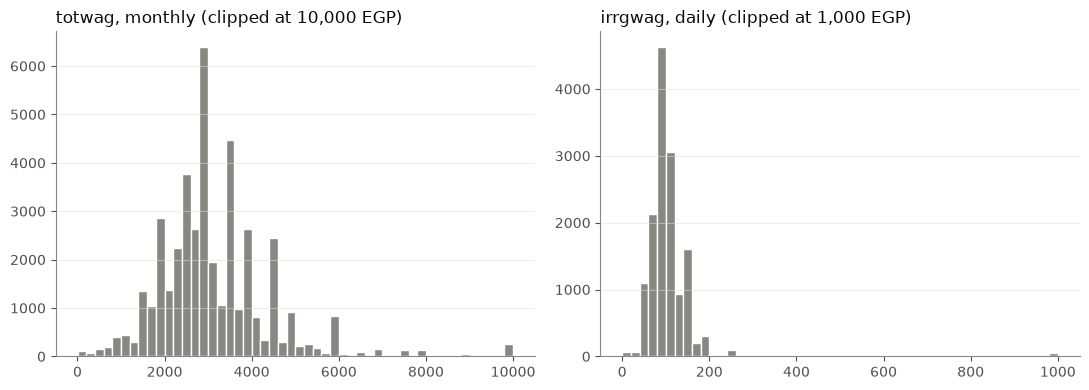

In [4]:
print(f"{len(wage_earners):,} people have a wage on record "
      f"({(wage_earners['sex']==1).sum():,} male, {(wage_earners['sex']==2).sum():,} female)")

fig, axes = plt.subplots(1, 2, figsize=(11,4))
wage_earners[wage_earners["totwag"]>0]["totwag"].clip(upper=10000).hist(bins=50, ax=axes[0], color=AXIS_C, edgecolor="white", grid=False)
axes[0].set_title("totwag, monthly (clipped at 10,000 EGP)", loc="left")
wage_earners[wage_earners["irrgwag"]>0]["irrgwag"].clip(upper=1000).hist(bins=50, ax=axes[1], color=AXIS_C, edgecolor="white", grid=False)
axes[1].set_title("irrgwag, daily (clipped at 1,000 EGP)", loc="left")
for a in axes: a.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

<small>Both right-skewed, long tail of high earners. No transform applied here, just what's actually in the raw data. We can answer wage-gap questions with this, but only for the people who actually have a wage. As the next question shows, that's not most agricultural workers.</small>

### Question 2: how does employment status differ by gender within agriculture

In [5]:
emps_labels = {1: "Employee (wage)", 2: "Employer", 3: "Self-employed", 4: "Unpaid family worker",
               5: "Producers cooperative", 6: "Not classifiable"}
ind_labels = {
    10: "Agriculture, forestry, fishing", 20: "Mining and quarrying", 30: "Manufacturing",
    40: "Electricity, gas, water supply", 50: "Construction", 60: "Wholesale and retail trade",
    70: "Transportation and storage", 80: "Accommodation and food service",
    90: "Information and communication", 100: "Financial and insurance",
    110: "Real estate, professional, support services", 120: "Public administration and defense",
    130: "Education", 140: "Human health and social work", 150: "Other activities",
}
employed = ind[ind["ind"].notna()].copy()
employed["industry"] = employed["ind"].map(ind_labels)
employed["employment_status"] = employed["emps"].map(emps_labels)

agri = employed[employed["ind"]==10]
agri.sample(5, random_state=3)[["sex","age","employment_status","totwag","irrgwag","hrswk"]]

,sex,age,employment_status,totwag,irrgwag,hrswk
233554,1,20,Unpaid family worker,NaN,NaN,50.0
217031,1,20,Employee (wage),NaN,130.0,36.0
220568,1,47,Employee (wage),NaN,150.0,35.0
286431,1,31,Employee (wage),NaN,100.0,40.0
89964,1,19,Unpaid family worker,NaN,NaN,50.0


In [6]:
print(pd.crosstab(agri["employment_status"], agri["sex"].map({1:"Male",2:"Female"})))

sex                   Female  Male
employment_status                 
Employee (wage)          391  7746
Employer                   5   154
Self-employed            110  4588
Unpaid family worker    1641  1027


<small>Women in agriculture are mostly unpaid family workers. Men are mostly wage employees or self-employed. This is the real reason a wage-only analysis misses most women's agricultural work: it's not that women aren't working, it's that they're not being paid directly for it.</small>

### Question 3: what does hours worked / underemployment look like

In [7]:
has_hours = ind[ind["hrswk"]>0]
has_hours.sample(5, random_state=4)[["sex","age","ind","emps","hrswk","totwag","irrgwag"]]

,sex,age,ind,emps,hrswk,totwag,irrgwag
161509,1,43,40.0,1.0,35.0,3800.0,NaN
23191,1,47,50.0,1.0,50.0,3000.0,NaN
256499,1,20,10.0,1.0,40.0,NaN,80.0
75294,2,33,140.0,1.0,48.0,3000.0,NaN
162764,1,39,30.0,1.0,48.0,4300.0,NaN


In [8]:
hours_by_sex = has_hours["sex"].value_counts()
print(f"{len(has_hours):,} people have hours data ({hours_by_sex.get(1,0):,} male, {hours_by_sex.get(2,0):,} female)")
print(f"vs {len(wage_earners):,} with wage data ({(wage_earners['sex']==2).sum():,} female)")

76,011 people have hours data (64,274 male, 11,737 female)
vs 56,065 with wage data (8,260 female)


<small>Roughly double the people have hours data vs. wage data. The gap is the unpaid family workers, who are working (hours recorded) but not paid (no wage variable exists for them at all).</small>

### Question 4: is occupation segregated by gender

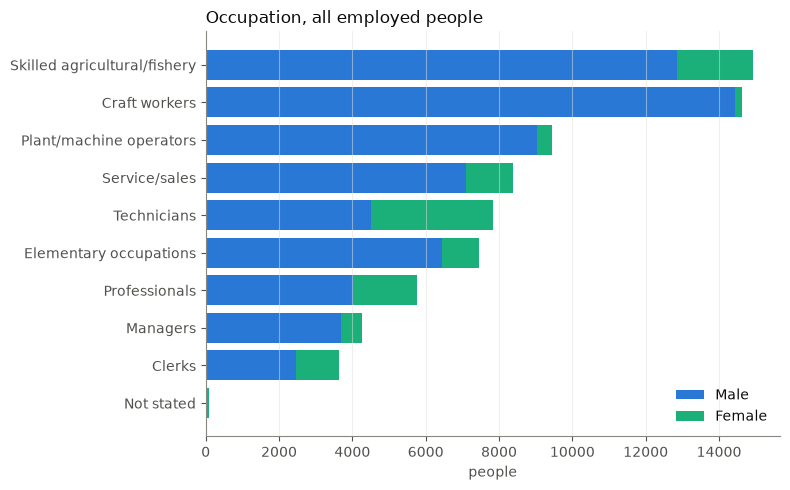

In [9]:
occ_labels = {10:"Managers",20:"Professionals",30:"Technicians",40:"Clerks",50:"Service/sales",
              60:"Skilled agricultural/fishery",70:"Craft workers",80:"Plant/machine operators",
              90:"Elementary occupations",100:"Armed forces",998:"Other",999:"Not stated"}
employed["occupation"] = employed["occ"].map(occ_labels)
occ_counts = employed.groupby(["occupation","sex"]).size().unstack(fill_value=0).rename(columns={1:"Male",2:"Female"})
occ_counts["Total"] = occ_counts["Male"]+occ_counts["Female"]
occ_counts = occ_counts.sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(8,5))
ax.barh(occ_counts.index, occ_counts["Male"], color=MALE_C, label="Male")
ax.barh(occ_counts.index, occ_counts["Female"], left=occ_counts["Male"], color=FEMALE_C, label="Female")
ax.set_title("Occupation, all employed people", loc="left")
ax.set_xlabel("people")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.show()

<small>"Skilled agricultural/fishery" is the single biggest occupation group. We checked this against `ind` earlier and they agree closely for agriculture (95% overlap), so we're not using `occ` as a second filter, just as a cross-check.</small>

### Supporting checks: industries, workplace, employment stability, geography, migration

<small>These don't answer a headline question on their own, but they're context we needed to trust the answers above.</small>

**Industries, full distribution** (not just within agriculture, like Question 2 above).

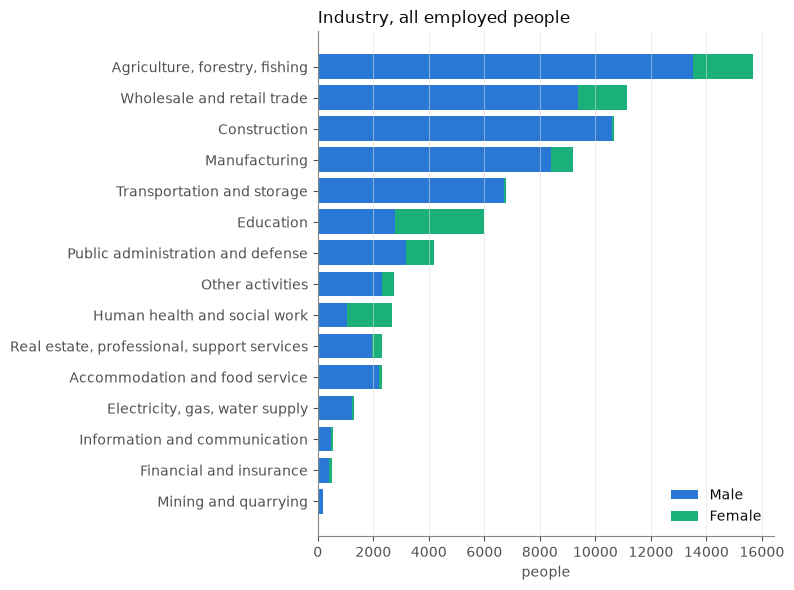

In [10]:
counts = employed.groupby(["industry","sex"]).size().unstack(fill_value=0).rename(columns={1:"Male",2:"Female"})
counts["Total"] = counts["Male"]+counts["Female"]
counts = counts.sort_values("Total", ascending=True)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(counts.index, counts["Male"], color=MALE_C, label="Male")
ax.barh(counts.index, counts["Female"], left=counts["Male"], color=FEMALE_C, label="Female")
ax.set_title("Industry, all employed people", loc="left")
ax.set_xlabel("people")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.show()

**Where the work happens**, within agriculture specifically: cross-checking that `wrkplc` agrees with `ind==10`.

In [11]:
wrkplc_labels = {1:"In own home",2:"In someone else's home",3:"Premises adjacent to home",
                  4:"Exclusive premises (office/shop/factory)",5:"Street vendor, fixed location",
                  6:"Street vendor, mobile",7:"Kiosk/hut",8:"Transportation vehicle",
                  9:"Construction site",10:"Agriculture land/maritime area",90:"Other",99:"Not stated"}
agri_workplace = employed[employed["ind"]==10]["wrkplc"].map(wrkplc_labels).value_counts()
print("workplace, within ind==agriculture:")
print(agri_workplace)

workplace, within ind==agriculture:
wrkplc
Agriculture land/maritime area              3371
Street vendor, mobile                        229
Exclusive premises (office/shop/factory)      72
In own home                                   60
Other                                         41
In someone else's home                         4
Transportation vehicle                         3
Name: count, dtype: int64


<small>Code 10 is literally "Agriculture land/maritime area." That confirms the ind==10 farm workers are actually working the land, not just administratively coded that way.</small>

**Employment stability**, within agriculture: regular vs. seasonal/irregular, by sex.

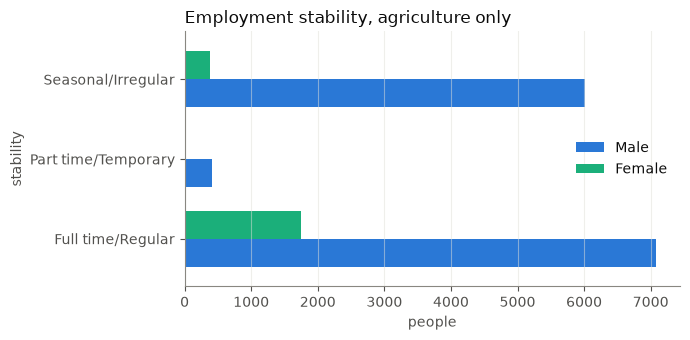

In [12]:
empstab_labels = {1:"Full time/Regular",2:"Part time/Temporary",3:"Seasonal/Irregular"}
agri2 = agri.copy()
agri2["stability"] = agri2["empstab"].map(empstab_labels)
stab_counts = agri2.groupby(["stability","sex"]).size().unstack(fill_value=0).rename(columns={1:"Male",2:"Female"})

fig, ax = plt.subplots(figsize=(7,3.5))
stab_counts.plot(kind="barh", ax=ax, color=[MALE_C,FEMALE_C], width=0.7)
ax.set_title("Employment stability, agriculture only", loc="left")
ax.set_xlabel("people")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.show()

**How fine does the geography get?** AREA is not generated for Egypt (`Key = '/'` in the dictionary). Governorate x urban/rural is as fine as this survey gets, no district level.

**Migration status**: most people report no migration; small internal/international groups exist.

In [13]:
print(ind["immigr"].map({1:"Immigrant (from abroad)",2:"Migrant (internal)",3:"No"}).value_counts())

immigr
No                         61788
Migrant (internal)          2432
Immigrant (from abroad)     1037
Name: count, dtype: int64


**The child-labor edge case**: LFS's own universe for wage/hours is "aged 6+."

In [14]:
print("wage earners under 15:", (wage_earners["age"]<15).sum())
print("youngest wage earner:", wage_earners["age"].min())

wage earners under 15: 136
youngest wage earner: 8


<small>Small numbers but real: LFS's own universe for wage/hours is "aged 6+," and there's at least one 8-year-old with a wage on record. What to do about it is a modeling decision, not something we're resolving here.</small>

**Where people live**: wage-earners by governorate.

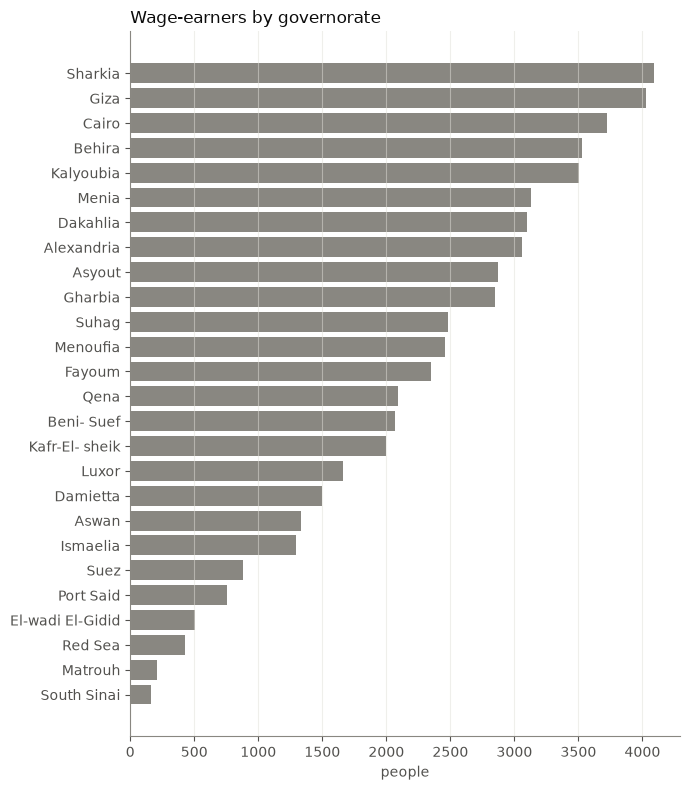

In [15]:
crosswalk = pd.read_csv(REPO_ROOT / "Data" / "crosswalk" / "reg_governorate_crosswalk.csv")
wage_by_gov = wage_earners.merge(crosswalk[["reg_code","reg_name_lfs"]], left_on="reg", right_on="reg_code", how="left")
gov_counts = wage_by_gov["reg_name_lfs"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7,8))
ax.barh(gov_counts.index, gov_counts.values, color=AXIS_C)
ax.set_title("Wage-earners by governorate", loc="left")
ax.set_xlabel("people")
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.show()

# Part 2: what the household file can answer

In [16]:
hh.sample(5, random_state=5)[["caseser","tpnum","sexhd","agehd","totwaghd","agesp_1","totwagsp_1"]]

,caseser,tpnum,sexhd,agehd,totwaghd,agesp_1,totwagsp_1
31330,1.403313e+11,4,1,41,2600.0,33.0,NaN
76921,3.502011e+11,6,1,38,3500.0,31.0,NaN
51879,2.111083e+11,5,1,28,NaN,25.0,NaN
49370,1.910062e+11,3,1,35,4500.0,23.0,NaN
7535,1.350412e+10,1,2,74,NaN,NaN,NaN


<small>One row per household: the head's and up to 3 spouses' info spread across columns, rather than one row per person.</small>

### Question 1: how prevalent is female headship

In [17]:
print(hh["sexhd"].value_counts())
print(f"{(hh['sexhd']==2).sum():,} of {len(hh):,} households ({(hh['sexhd']==2).mean()*100:.0f}%) are female-headed")

sexhd
1    62161
2    14815
Name: count, dtype: int64
14,815 of 76,976 households (19%) are female-headed


### Question 2: what does household size and composition look like

In [18]:
print(hh["tpnum"].describe())

count    76976.000000
mean         3.889823
std          1.726798
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         17.000000
Name: tpnum, dtype: float64


### What this file can't tell us

In [19]:
check_terms = ["electric","water","energy","fuel","light","cook","toilet","sanitation"]
found = [c for c in hh.columns if any(t in c.lower() for t in check_terms)]
print("dwelling/utility columns found in the household file:", found)

dwelling/utility columns found in the household file: []


<small>None. We checked directly: LFS's household file has no electricity, water-source, or
sanitation data at all. That kind of dwelling-characteristics data exists in ECGBVS 2015, not
here. We're flagging the absence rather than working around it.</small>

# Part 3: what only combining the two files can tell us

<small>Both files share `caseser` (household ID). We confirmed 100% overlap, no duplicates
within a household, so we can always link a household row to its members or the other way
round.</small>

### Question 1: what share of a household's earners does the household file's wage columns actually miss

In [20]:
wage_ind = ind[(ind["totwag"]>0)|(ind["irrgwag"]>0)]
rel_labels = {1:"Head",2:"Spouse",3:"Son/daughter",4:"Parent",5:"Sibling",6:"Grandchild",7:"Other relative",8:"Non-relative"}
print(f"{len(wage_ind):,} total wage-earners in the individual file")
print(wage_ind["rel"].map(rel_labels).value_counts())

not_head_or_spouse = wage_ind[~wage_ind["rel"].isin([1,2])]
print(f"\n{len(not_head_or_spouse):,} wage-earners are neither head nor spouse "
      f"({len(not_head_or_spouse)/len(wage_ind)*100:.0f}% of all wage-earners)")

56,065 total wage-earners in the individual file
rel
Head              36164
Son/daughter      14006
Spouse             5141
Sibling             314
Other relative      219
Grandchild          142
Parent               49
Non-relative         30
Name: count, dtype: int64

14,760 wage-earners are neither head nor spouse (26% of all wage-earners)


<small>About a quarter of all wage-earners are sons, daughters, or other relatives, not head
or spouse. The household file's own wage columns (`totwaghd`, `totwagsp_1-3`) don't capture any of
them. Only the individual file sees everyone.</small>

**Sanity check**: are the two files at least consistent for who they both can see (head and spouse)?

In [21]:
print("head wage-earners, individual file (rel==1):", (wage_ind["rel"]==1).sum())
print("head wage-earners, household file:", ((hh["totwaghd"]>0)|(hh["irrgwaghd"]>0)).sum())
print()
print("spouse-1 wage-earners, individual file (rel==2):", (wage_ind["rel"]==2).sum())
print("spouse-1 wage-earners, household file:", ((hh["totwagsp_1"]>0)|(hh["irrgwagsp_1"]>0)).sum())

head wage-earners, individual file (rel==1): 36164
head wage-earners, household file: 36164

spouse-1 wage-earners, individual file (rel==2): 5141
spouse-1 wage-earners, household file: 5128


<small>Head counts match exactly, spouse counts are close. The two files agree where they overlap.</small>

# Part 4: the core comparison (rural agriculture, men vs. women)

<small>Putting hours and wage together, restricted to rural agriculture specifically, and checked
two ways: across the whole population, and within the same household. If both views agree, that's
a well-triangulated finding, not just a population-level artifact.</small>

### Individual level: hours and wage, rural agriculture only

In [22]:
import numpy as np

rural_agri = ind[(ind["ind"] == 10) & (ind["rururb"] == 0)].copy()
rural_agri_hours = rural_agri[rural_agri["hrswk"] > 0].copy()

print("Hours worked, rural agriculture, by sex:")
print(rural_agri_hours.groupby(rural_agri_hours["sex"].map({1: "Male", 2: "Female"}))["hrswk"]
      .agg(["count", "mean", "median"]).round(1))

Hours worked, rural agriculture, by sex:
        count  mean  median
sex                        
Female   2016  32.0    35.0
Male    12072  42.7    42.0


In [23]:
WEEKS_PER_MONTH = 365.25 / 7 / 12
rural_agri_wage = rural_agri_hours[(rural_agri_hours["totwag"] > 0) | (rural_agri_hours["irrgwag"] > 0)].copy()
is_reg = rural_agri_wage["totwag"] > 0
rural_agri_wage["hourly_wage"] = np.where(
    is_reg, rural_agri_wage["totwag"] / (rural_agri_wage["hrswk"] * WEEKS_PER_MONTH),
    rural_agri_wage["irrgwag"] / (rural_agri_wage["hrswk"] / 7)
)

print("Hourly wage, rural agriculture wage-earners, by sex:")
print(rural_agri_wage.groupby(rural_agri_wage["sex"].map({1: "Male", 2: "Female"}))["hourly_wage"]
      .agg(["count", "mean", "median"]).round(2))

Hourly wage, rural agriculture wage-earners, by sex:
        count   mean  median
sex                         
Female    363  18.93   15.31
Male     6809  18.81   15.56


<small>Both gaps show up in the same direction, restricted to exactly the population the paper is
about, not the broader "all industries" numbers from Part 1.</small>

### Household level: does the gap hold up within the same household?

<small>Rather than comparing men and women across the whole population, this checks whether the
gap holds even when comparing men and women who live in the *same household*, a sharper test than
a population-level average.</small>

In [24]:
hh_gender_hours = rural_agri_hours.groupby(["caseser", "sex"])["hrswk"].sum().unstack(fill_value=0)
hh_gender_hours.columns = ["male_hours", "female_hours"] if list(hh_gender_hours.columns) == [1, 2] else hh_gender_hours.columns
hh_gender_hours = hh_gender_hours.rename(columns={1: "male_hours", 2: "female_hours"})

both_present = hh_gender_hours[(hh_gender_hours.get("male_hours", 0) > 0) & (hh_gender_hours.get("female_hours", 0) > 0)]
print(f"{len(hh_gender_hours)} households have at least one rural agricultural worker with hours")
print(f"{len(both_present)} of those have BOTH a male and a female agricultural worker")
print()
print("Within those households:")
print(f"  mean male hours:   {both_present['male_hours'].mean():.1f}")
print(f"  mean female hours: {both_present['female_hours'].mean():.1f}")

10895 households have at least one rural agricultural worker with hours
1451 of those have BOTH a male and a female agricultural worker

Within those households:
  mean male hours:   52.8
  mean female hours: 32.4


<small>Small sample: most households with a rural agricultural worker only have one sex
represented, since agricultural work in a given household tends to be done by either the men or
the women, not evenly split. Worth knowing this comparison is thin before leaning on it too hard.</small>

### Does the gap vary by governorate?

<small>If the gap is roughly the same everywhere, that's a weaker case that local factors (like
water management specifically) drive it. If it varies a lot, that's more consistent with the
paper's premise.</small>

In [25]:
rural_agri_hours_gov = rural_agri_hours.merge(crosswalk[["reg_code", "reg_name_lfs"]], left_on="reg", right_on="reg_code", how="left")
gov_gap = rural_agri_hours_gov.groupby(["reg_name_lfs", rural_agri_hours_gov["sex"].map({1: "Male", 2: "Female"})])["hrswk"].mean().unstack()
gov_n = rural_agri_hours_gov.groupby("reg_name_lfs").size()
gov_gap["gap"] = gov_gap["Male"] - gov_gap["Female"]
gov_gap["n"] = gov_n
print(gov_gap.sort_values("gap", ascending=False).round(1))

sex               Female  Male   gap     n
reg_name_lfs                              
Qena                11.2  35.4  24.2   700
Behira              26.6  48.9  22.3  1900
Suhag               28.0  48.3  20.3   843
El-wadi El-Gidid    26.5  44.0  17.5    87
Damietta            36.5  49.4  12.9   278
Kalyoubia           33.7  44.0  10.3   300
Kafr-El- sheik      39.4  49.0   9.6  1108
Sharkia             35.1  44.6   9.5  1067
Beni- Suef          29.9  38.9   8.9  1043
Menia               34.2  42.7   8.5  1562
Menoufia            30.7  38.9   8.3   555
Fayoum              36.4  44.5   8.1   820
Asyout              28.8  36.9   8.1   843
Ismaelia            31.5  39.5   8.0   316
Gharbia             28.1  34.6   6.5   682
Dakahlia            31.9  38.0   6.1   887
Giza                41.0  39.8  -1.2   281
Aswan                NaN  45.1   NaN   331
Luxor                NaN  34.6   NaN   440
Matrouh              NaN  53.4   NaN    32
South Sinai          NaN  34.3   NaN    13


<small>Read the small-`n` rows with caution: a handful of observations can swing a mean a lot.
But the gap clearly isn't a flat, uniform number across governorates.</small>

### Does education narrow the gap?

In [26]:
educ_labels_p4 = {1: "None", 2: "Primary/Lower secondary", 3: "Secondary",
                  4: "Post secondary", 5: "University", 6: "Postgraduate"}
rural_agri_hours["educ_label"] = rural_agri_hours["educ"].map(educ_labels_p4)
educ_gap = rural_agri_hours.groupby(["educ_label", rural_agri_hours["sex"].map({1: "Male", 2: "Female"})])["hrswk"].mean().unstack()
educ_n = rural_agri_hours.groupby("educ_label").size()
educ_gap["gap"] = educ_gap["Male"] - educ_gap["Female"]
educ_gap["n"] = educ_n
print(educ_gap.round(1))

sex                      Female  Male   gap     n
educ_label                                       
None                       31.9  42.8  10.9  6627
Post secondary             33.3  41.5   8.2   153
Postgraduate               30.0  35.6   5.6     8
Primary/Lower secondary    30.8  41.6  10.8  2303
Secondary                  33.2  43.1   9.9  4527
University                 30.6  44.3  13.7   465


### Does the gap look different by age

In [27]:
age_bins = [15, 25, 35, 45, 55, 100]
age_bin_labels = ["15-24", "25-34", "35-44", "45-54", "55+"]
rural_agri_hours["age_group"] = pd.cut(rural_agri_hours["age"], bins=age_bins, labels=age_bin_labels, right=False)
age_gap = rural_agri_hours.groupby(["age_group", rural_agri_hours["sex"].map({1: "Male", 2: "Female"})], observed=True)["hrswk"].mean().unstack()
age_n = rural_agri_hours.groupby("age_group", observed=True).size()
age_gap["gap"] = age_gap["Male"] - age_gap["Female"]
age_gap["n"] = age_n
print(age_gap.round(1))

sex        Female  Male   gap     n
age_group                          
15-24        32.1  40.9   8.8  2064
25-34        30.7  43.5  12.8  3135
35-44        33.4  44.7  11.3  3298
45-54        32.3  44.1  11.8  2676
55+          30.6  40.3   9.7  2833


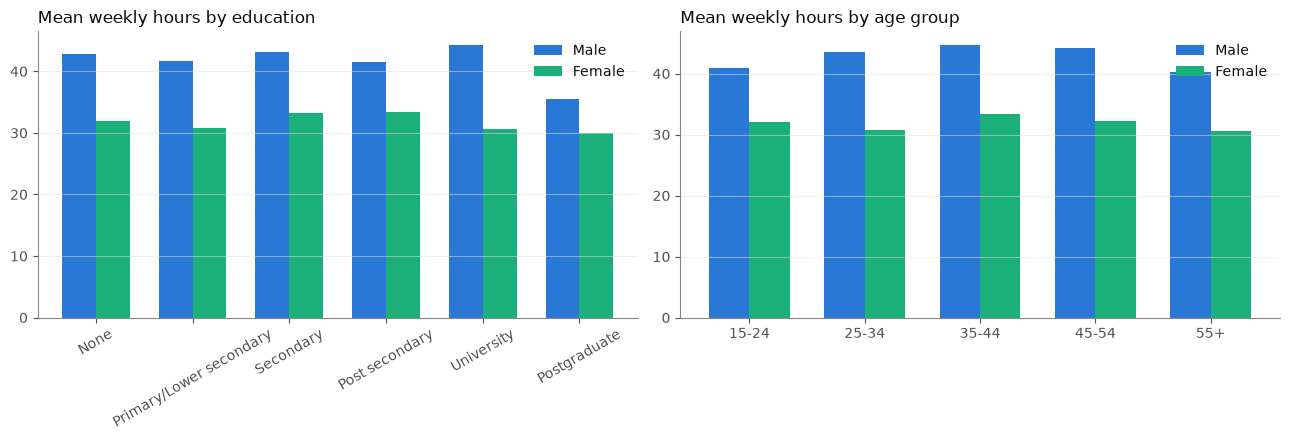

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

educ_plot = educ_gap[["Male", "Female"]].reindex(["None", "Primary/Lower secondary", "Secondary", "Post secondary", "University", "Postgraduate"])
educ_plot.plot(kind="bar", ax=axes[0], color=[MALE_C, FEMALE_C], width=0.7)
axes[0].set_title("Mean weekly hours by education", loc="left")
axes[0].set_xlabel("")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.5)
axes[0].tick_params(axis="x", rotation=30)

age_plot = age_gap[["Male", "Female"]]
age_plot.plot(kind="bar", ax=axes[1], color=[MALE_C, FEMALE_C], width=0.7)
axes[1].set_title("Mean weekly hours by age group", loc="left")
axes[1].set_xlabel("")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.5)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Part 4 summary

<small>
- Restricted to rural agriculture specifically, both hours and wage show a gap by sex, in the same
  direction as the broader population numbers in Part 1.
- The gap holds up within the same household too, though the usable sample for that specific
  comparison is thin: most households with an agricultural worker only have one sex represented.
- The gap is not uniform across governorates: some show a much bigger gap than others.
- Education and age both look worth a closer, more careful look (not just a first-pass mean
  comparison) before drawing a conclusion from either.
</small>

### Summary

<small>
<b>The core finding (Part 4)</b>: restricted to rural agriculture specifically (the population
this paper is actually about), men work more hours than women (42.7 vs. 32.0 mean weekly hours),
while the hourly wage gap among the paid subsample is close to zero (18.81 vs. 18.93 EGP/hour).
The gap holds up within the same household, isn't uniform across governorates, and shows up
across education levels and age groups. This is the empirical case for treating hours worked, not
wage, as the primary outcome: wage alone would have suggested there's barely a gender gap here at
all.<br><br>
<b>Individual file</b> answers: is there a wage gap, how does employment status differ by
gender, what does hours/underemployment look like, is occupation segregated by gender. 299,423
rows. Agriculture is the biggest industry and occupation. Women in agriculture: mostly unpaid
family workers. Men: mostly wage employees or self-employed. AREA (finer than governorate)
doesn't exist for Egypt.<br><br>
<b>Household file</b> answers: how prevalent is female headship (19%), what household composition
looks like (~4 people average). No electricity/water/sanitation data at all.<br><br>
<b>Combining both</b> answers: what share of earners the household file's wage columns miss
(26%, all non-head/spouse relatives), and whether the two files agree where they overlap (yes).
</small>